### Instruksi Pengerjaan

---

**A. Membangun Struktur Direktori HDFS** *(bobot 15%)*

Buatlah struktur direktori berikut di HDFS:
```
/user/[username]/ecommerce/raw
/user/[username]/ecommerce/processed
```
Tampilkan hasilnya untuk membuktikan struktur sudah terbentuk.

In [7]:
# (A) Membangun Struktur Direktori HDFS
!hdfs dfs -mkdir -p /user/jauharaputri/ecommerce/raw
!hdfs dfs -mkdir -p /user/jauharaputri/ecommerce/processed

# Menampilkan isi direktori root HDFS untuk verifikasi
!hdfs dfs -ls /user/jauharaputri/ecommerce

Found 2 items
drwxr-xr-x   - jauharaputri supergroup          0 2026-09-08 19:21 /user/jauharaputri/ecommerce/processed
drwxr-xr-x   - jauharaputri supergroup          0 2026-09-08 19:21 /user/jauharaputri/ecommerce/raw


---
**B. Mengunggah Data Mentah ke HDFS** *(bobot 15%)*

Unggah **ketiga berkas CSV** (`transaksi_magelang.csv`, `transaksi_yogyakarta.csv`, `transaksi_semarang.csv`) ke direktori `/user/[username]/ecommerce/raw` di HDFS. Tampilkan isi direktori tersebut sebagai bukti ketiga berkas berhasil terunggah, lengkap dengan ukurannya.

In [10]:
# (B) Mengunggah Data Mentah ke HDFS
!hdfs dfs -put transaksi_*.csv /user/jauharaputri/ecommerce/raw

# Verifikasi berkas sudah ada di HDFS
!hdfs dfs -ls /user/jauharaputri/ecommerce/raw

# -du: menampilkan ukuran penggunaan disk di HDFS
print('\nUkuran ketiga berkas:')
!hdfs dfs -du -h /user/jauharaputri/ecommerce/raw

put: `/user/jauharaputri/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/user/jauharaputri/ecommerce/raw/transaksi_semarang.csv': File exists
put: `/user/jauharaputri/ecommerce/raw/transaksi_yogyakarta.csv': File exists
Found 3 items
-rw-r--r--   1 jauharaputri supergroup      12329 2026-09-08 19:29 /user/jauharaputri/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 jauharaputri supergroup      12154 2026-09-08 19:29 /user/jauharaputri/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 jauharaputri supergroup      12684 2026-09-08 19:29 /user/jauharaputri/ecommerce/raw/transaksi_yogyakarta.csv

Ukuran ketiga berkas:
12.0 K  12.0 K  /user/jauharaputri/ecommerce/raw/transaksi_magelang.csv
11.9 K  11.9 K  /user/jauharaputri/ecommerce/raw/transaksi_semarang.csv
12.4 K  12.4 K  /user/jauharaputri/ecommerce/raw/transaksi_yogyakarta.csv


---
**C. Membaca Kembali dan Menggabungkan Data dari HDFS** *(bobot 25%)*

Menggunakan Python, baca kembali **ketiga berkas dari HDFS** (bukan dari disk lokal!). Gabungkan ketiganya menjadi **satu DataFrame**, lalu buktikan hasil gabungan berisi transaksi dari ketiga kota (tampilkan `value_counts()` pada kolom `kota`).

In [12]:
# (C) Membaca Kembali dan Menggabungkan Data dari HDFS
import pandas as pd
from io import StringIO
import subprocess

def baca_hdfs(file):
    data = subprocess.check_output(["hdfs", "dfs", "-cat", file]).decode()
    return pd.read_csv(StringIO(data))

df1 = baca_hdfs("/user/jauharaputri/ecommerce/raw/transaksi_magelang.csv")
df2 = baca_hdfs("/user/jauharaputri/ecommerce/raw/transaksi_yogyakarta.csv")
df3 = baca_hdfs("/user/jauharaputri/ecommerce/raw/transaksi_semarang.csv")

df = pd.concat([df1, df2, df3], ignore_index=True)

df["kota"].value_counts()

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

---
**D. Mengolah dan Download Hasil ke Direktori `processed`** *(bobot 25%)*

Pada DataFrame gabungan hasil bagian C:
1. Tambahkan kolom `total_pendapatan` (`unit_terjual x harga_satuan`).
2. Buatlah **satu tabel ringkasan** (`groupby`) yang menampilkan total pendapatan per kota **dan** per kategori sekaligus.
3. Simpan **dua** hasil berikut sebagai berkas CSV baru di disk lokal, lalu unggah keduanya ke `/user/[username]/ecommerce/processed` di HDFS:
   - `data_gabungan_bersih.csv` (seluruh data ketiga kota yang telah digabung + kolom `total_pendapatan`)
   - `ringkasan_kota_kategori.csv` (tabel ringkasan dari langkah 2)

In [18]:
# (D) Mengolah dan Download Hasil ke Direktori processed
df["total_pendapatan"] = df["unit_terjual"] * df["harga_satuan"]

ringkasan = df.groupby(["kota", "kategori"])["total_pendapatan"].sum().reset_index()

df.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

!hdfs dfs -put -f data_gabungan_bersih.csv /user/jauharaputri/ecommerce/processed/
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/jauharaputri/ecommerce/processed/

!hdfs dfs -ls -h /user/jauharaputri/ecommerce/processed

Found 2 items
-rw-r--r--   1 jauharaputri supergroup     40.3 K 2026-09-09 17:34 /user/jauharaputri/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 jauharaputri supergroup        530 2026-09-09 17:35 /user/jauharaputri/ecommerce/processed/ringkasan_kota_kategori.csv


---
**E. Dokumentasi dan Refleksi** *(bobot 20%)*

Sertakan pada notebook anda:
1. **Screenshot** halaman NameNode Web UI (http://localhost:9870, menu *Utilities → Browse the file system*) yang menunjukkan struktur folder `/user/[username]/ecommerce/` beserta isinya (paste gambar ke dalam markdown cell, atau lampirkan terpisah jika format pengumpulan berupa arsip/zip.
2. Tulisan reflektif (**minimal 100 kata**) pada markdown cell yang menjawab: *Apa keuntungan menyimpan data mentah (raw) terpisah dari data olahan (processed) di HDFS, dibandingkan menyimpan semuanya bercampur dalam satu folder?*

---

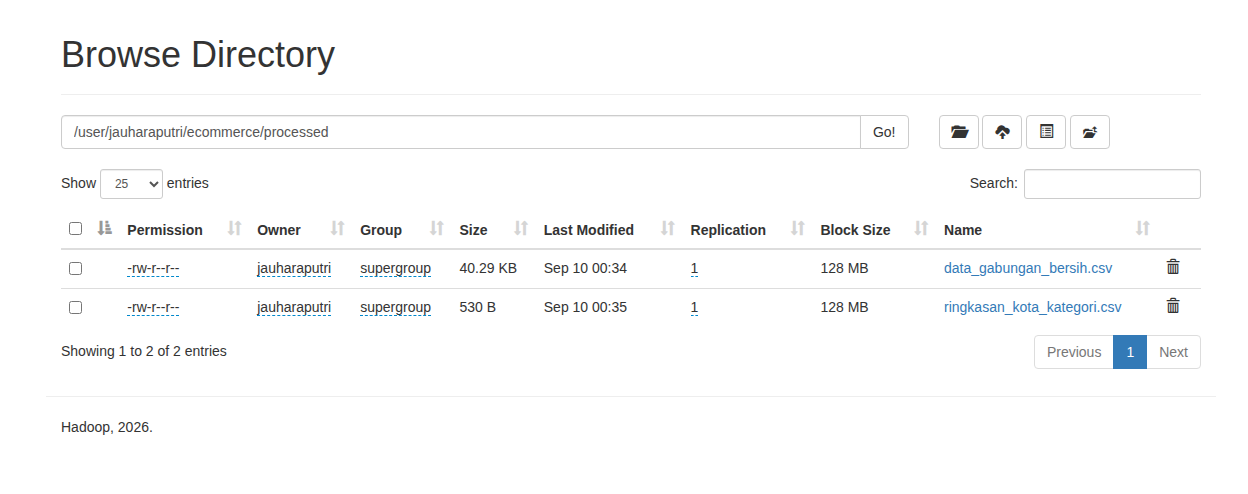
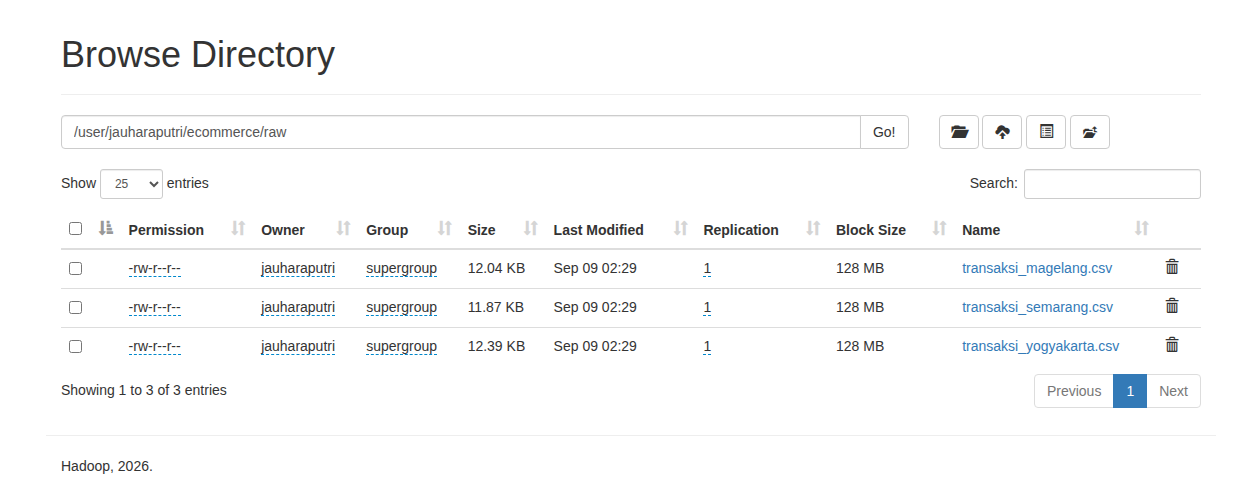

Keuntungan menyimpan data mentah terpisah dari data olahan di HDFS yaitu apabila ada kesalahan logika pada algoritma pemrosesan, data olahan dapat dihapus dan diproses ulang dari data mentah. Data mentah juga disimpan dalam format aslinya tanpa mengalami perubahan, sehingga lebih aman untuk digunakan kembali. Selain itu, pemisahan data ini membuat pengelolaan data mentah dan data olahan menjadi lebih terstruktur dan mudah dibedakan. Apabila data mentah dan data olahan digabung dalam satu folder, besar kemungkinan format asli dapat berubah atau bahkan hilang tanpa kita ketahui. Oleh karenanya, pemisahan ini terjadi untuk membuat pengelolaan data di HDFS lebih rapi, aman, dan terstruktur.